# Métodos Numéricos I — Notebook da Aula 3
## Interpolação Polinomial: Lagrange, Newton e Fenômeno de Runge

**Programa:** PPGMC / UESC  
**Referências-base:** Burden & Faires cap. 3; Epperson cap. 4.

Este notebook foi preparado para apoiar a **Aula 3 — Interpolação Polinomial**.

## Objetivos
- apresentar o **problema da interpolação**;
- construir o **polinômio interpolador**;
- comparar as formas de **Lagrange** e **Newton**;
- introduzir **diferenças divididas**;
- analisar o **erro de interpolação**;
- visualizar o **fenômeno de Runge**.

## 1. Bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

## 2. Problema da interpolação

Dado um conjunto de pontos distintos

$$ (x_0, y_0), (x_1, y_1), \dots, (x_n, y_n),$$

queremos encontrar um polinômio $(P_n(x))$ tal que

$$
P_n(x_i) = y_i, \quad i=0,1,\dots,n.
$$

Se os pontos $(x_i)$ são distintos, existe um único polinômio de grau no máximo $(n)$ que satisfaz essa condição.

## 3. Exemplo-base da aula

Usaremos inicialmente os pontos:

$$
(1,2), (2,3), (4,7).
$$

Eles serão usados tanto na forma de **Lagrange** quanto na forma de **Newton**.

Pontos:
(1.0, 2.0)
(2.0, 3.0)
(4.0, 7.0)


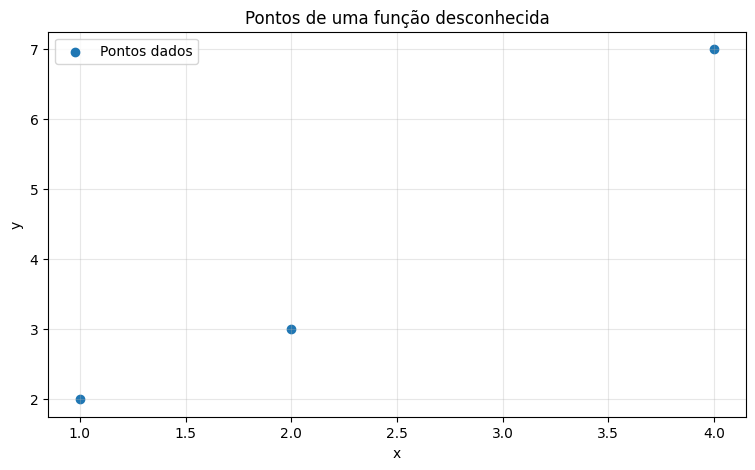

In [20]:
xs = np.array([1.0, 2.0, 4.0])
ys = np.array([2.0, 3.0, 7.0])

print("Pontos:")
for x, y in zip(xs, ys):
    print(f"({x}, {y})")

plt.figure(figsize=(9,5))
plt.scatter(xs, ys, label="Pontos dados")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Pontos de uma função desconhecida")
plt.legend()
plt.show()

## 4. Interpolação de Lagrange

A forma de Lagrange é dada por

$$
P_n(x)=\sum_{i=0}^{n} y_i L_i(x),
$$

onde

$$
L_i(x)=\prod_{j=0, j\ne i}^{n} \frac{x-x_j}{x_i-x_j}.
$$

Cada polinômio básico $(L_i(x))$:
- vale 1 em $(x_i)$;
- vale 0 nos demais pontos.

In [3]:
def lagrange_basis(x, xs, i):
    L = 1.0
    for j in range(len(xs)):
        if j != i:
            L *= (x - xs[j]) / (xs[i] - xs[j])
    return L

def lagrange_interp(x, xs, ys):
    total = 0.0
    for i in range(len(xs)):
        total += ys[i] * lagrange_basis(x, xs, i)
    return total

### 4.1. Verificação dos polinômios básicos de Lagrange

In [4]:
for i in range(len(xs)):
    print(f"Polinômio básico L_{i}(x) avaliado nos nós:")
    for x in xs:
        print(f"  L_{i}({x}) = {lagrange_basis(x, xs, i):.6f}")
    print()

Polinômio básico L_0(x) avaliado nos nós:
  L_0(1.0) = 1.000000
  L_0(2.0) = -0.000000
  L_0(4.0) = 0.000000

Polinômio básico L_1(x) avaliado nos nós:
  L_1(1.0) = 0.000000
  L_1(2.0) = 1.000000
  L_1(4.0) = -0.000000

Polinômio básico L_2(x) avaliado nos nós:
  L_2(1.0) = -0.000000
  L_2(2.0) = 0.000000
  L_2(4.0) = 1.000000



### 4.2. Avaliando o polinômio interpolador

In [5]:
x_test = [1.0, 1.5, 2.0, 3.0, 4.0]

for x in x_test:
    print(f"P({x}) = {lagrange_interp(x, xs, ys):.6f}")

P(1.0) = 2.000000
P(1.5) = 2.416667
P(2.0) = 3.000000
P(3.0) = 4.666667
P(4.0) = 7.000000


### 4.3. Visualização da interpolação por Lagrange

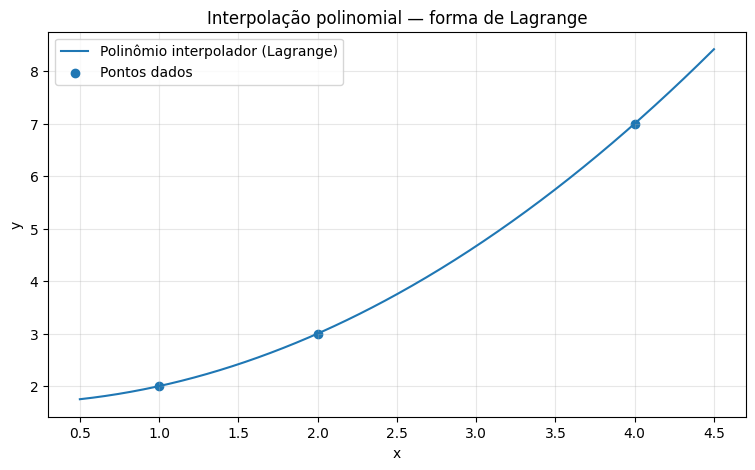

In [6]:
x_plot = np.linspace(0.5, 4.5, 400)
y_plot = np.array([lagrange_interp(x, xs, ys) for x in x_plot])

plt.figure(figsize=(9,5))
plt.plot(x_plot, y_plot, label="Polinômio interpolador (Lagrange)")
plt.scatter(xs, ys, label="Pontos dados")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolação polinomial — forma de Lagrange")
plt.legend()
plt.show()

## 5. Forma de Newton

A forma de Newton escreve o polinômio como

$$
P_n(x)=a_0 + a_1(x-x_0) + a_2(x-x_0)(x-x_1)+\cdots
$$

Os coeficientes $(a_i)$ são obtidos por **diferenças divididas**.

### 5.1. Diferenças divididas

Definições iniciais:

$$
f[x_i] = y_i
$$

$$
f[x_i, x_{i+1}] = \frac{f[x_{i+1}] - f[x_i]}{x_{i+1}-x_i}
$$

e, recursivamente,

$$
f[x_i, \dots, x_{i+k}] =
\frac{f[x_{i+1}, \dots, x_{i+k}] - f[x_i, \dots, x_{i+k-1}]}
{x_{i+k} - x_i}.
$$

In [7]:
def divided_differences(xs, ys):
    n = len(xs)
    table = np.zeros((n, n), dtype=float)
    table[:, 0] = ys

    for j in range(1, n):
        for i in range(n - j):
            table[i, j] = (table[i + 1, j - 1] - table[i, j - 1]) / (xs[i + j] - xs[i])

    return table

table = divided_differences(xs, ys)
table

array([[2.        , 1.        , 0.33333333],
       [3.        , 2.        , 0.        ],
       [7.        , 0.        , 0.        ]])

### 5.2. Tabela de diferenças divididas

A primeira linha da tabela contém os coeficientes da forma de Newton.

In [8]:
print("Tabela de diferenças divididas:")
for i in range(len(xs)):
    row = []
    for j in range(len(xs) - i):
        row.append(f"{table[i,j]:.6f}")
    print(row)

coef = table[0, :]
print("\nCoeficientes de Newton:", coef)

Tabela de diferenças divididas:
['2.000000', '1.000000', '0.333333']
['3.000000', '2.000000']
['7.000000']

Coeficientes de Newton: [2.         1.         0.33333333]


In [9]:
def newton_interp(x, xs, coef):
    result = coef[0]
    term = 1.0
    for i in range(1, len(xs)):
        term *= (x - xs[i-1])
        result += coef[i] * term
    return result

### 5.3. Avaliando a forma de Newton

In [10]:
for x in x_test:
    print(f"P({x}) = {newton_interp(x, xs, coef):.6f}")

P(1.0) = 2.000000
P(1.5) = 2.416667
P(2.0) = 3.000000
P(3.0) = 4.666667
P(4.0) = 7.000000


### 5.4. Comparação Lagrange × Newton

As duas formas produzem o **mesmo polinômio interpolador**, apenas representado de modo diferente.

In [11]:
for x in x_test:
    pl = lagrange_interp(x, xs, ys)
    pn = newton_interp(x, xs, coef)
    print(f"x = {x:.2f} | Lagrange = {pl:.10f} | Newton = {pn:.10f} | diferença = {abs(pl-pn):.3e}")

x = 1.00 | Lagrange = 2.0000000000 | Newton = 2.0000000000 | diferença = 0.000e+00
x = 1.50 | Lagrange = 2.4166666667 | Newton = 2.4166666667 | diferença = 4.441e-16
x = 2.00 | Lagrange = 3.0000000000 | Newton = 3.0000000000 | diferença = 0.000e+00
x = 3.00 | Lagrange = 4.6666666667 | Newton = 4.6666666667 | diferença = 8.882e-16
x = 4.00 | Lagrange = 7.0000000000 | Newton = 7.0000000000 | diferença = 0.000e+00


## 6. Comparação gráfica Lagrange × Newton

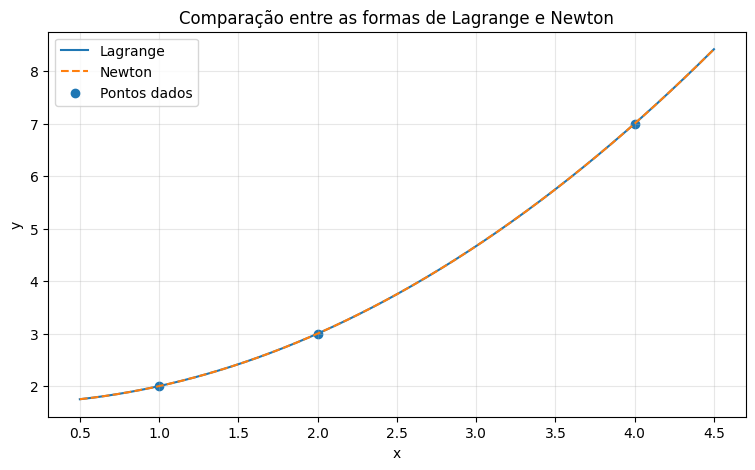

In [12]:
y_plot_l = np.array([lagrange_interp(x, xs, ys) for x in x_plot])
y_plot_n = np.array([newton_interp(x, xs, coef) for x in x_plot])

plt.figure(figsize=(9,5))
plt.plot(x_plot, y_plot_l, label="Lagrange")
plt.plot(x_plot, y_plot_n, "--", label="Newton")
plt.scatter(xs, ys, label="Pontos dados")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparação entre as formas de Lagrange e Newton")
plt.legend()
plt.show()

## 7. Observação computacional importante

Do ponto de vista numérico:

- a forma de **Lagrange** é conceitualmente elegante;
- a forma de **Newton** é mais conveniente computacionalmente;
- com Newton, é mais fácil **adicionar novos pontos** sem reconstruir tudo do zero.

## 8. Erro de interpolação

Se $(f)$ possui derivada de ordem $(n+1)$ contínua, então o erro é dado por

$$
f(x)-P_n(x)=\frac{f^{(n+1)}(\xi)}{(n+1)!}
\prod_{i=0}^{n}(x-x_i),
$$

para algum $(\xi)$ no intervalo.

Essa fórmula mostra que o erro depende de:
- da suavidade de $(f)$;
- da posição de $(x)$;
- da distribuição dos nós $(x_i)$.

## 9. Exemplo com função conhecida

Agora usaremos uma função conhecida para observar o erro de interpolação:

$$
f(x)=e^x
$$

com alguns pontos no intervalo $([0,1])$.

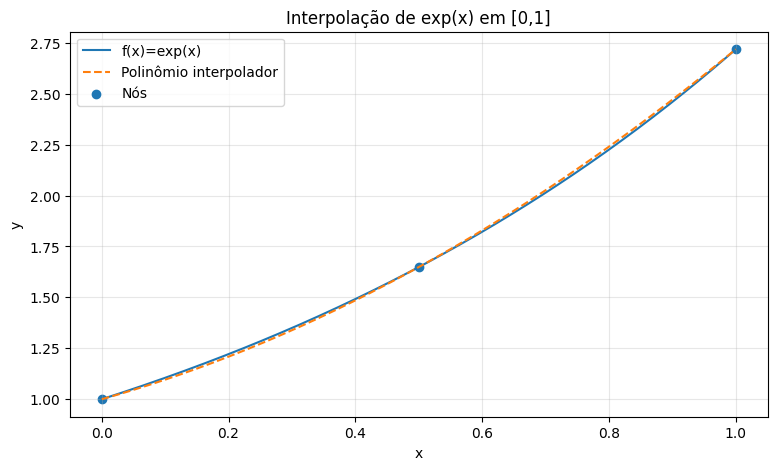

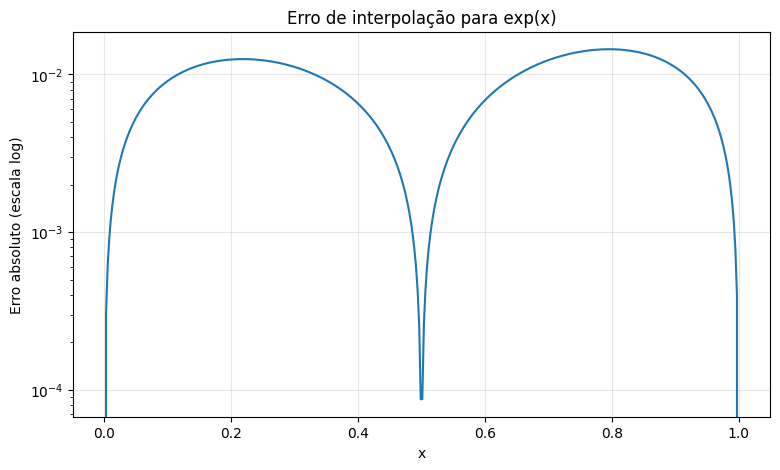

In [13]:
def f(x):
    return np.exp(x)

xs2 = np.array([0.0, 0.5, 1.0])
ys2 = f(xs2)

coef2 = divided_differences(xs2, ys2)[0, :]

x_plot = np.linspace(0, 1, 400)
y_real = f(x_plot)
y_interp = np.array([newton_interp(x, xs2, coef2) for x in x_plot])
erro = np.abs(y_real - y_interp)

plt.figure(figsize=(9,5))
plt.plot(x_plot, y_real, label="f(x)=exp(x)")
plt.plot(x_plot, y_interp, "--", label="Polinômio interpolador")
plt.scatter(xs2, ys2, label="Nós")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolação de exp(x) em [0,1]")
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.plot(x_plot, erro)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("Erro absoluto (escala log)")
plt.title("Erro de interpolação para exp(x)")
plt.show()

## 10. Fenômeno de Runge

Um exemplo clássico em interpolação polinomial é a função

$$
f(x)=\frac{1}{1+25x^2}, \quad x\in[-1,1].
$$

Quando usamos muitos pontos **igualmente espaçados**, o polinômio interpolador pode oscilar fortemente perto das extremidades do intervalo.

Esse comportamento é conhecido como **fenômeno de Runge**.

In [14]:
def runge(x):
    return 1 / (1 + 25*x**2)

### 10.1. Função de Runge

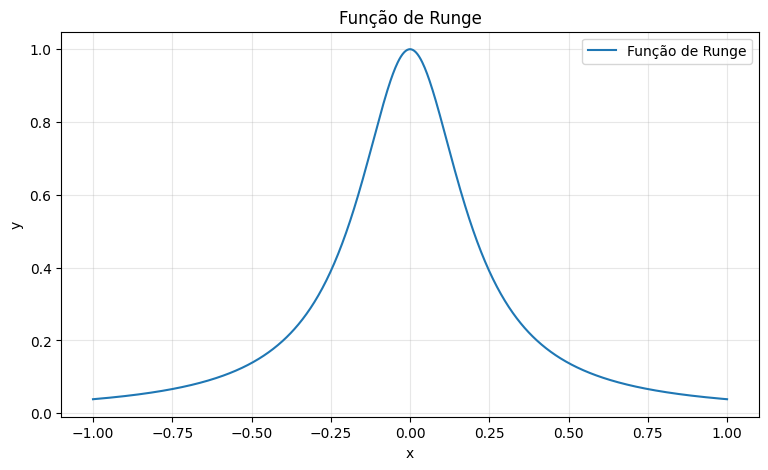

In [15]:
x = np.linspace(-1, 1, 800)
plt.figure(figsize=(9,5))
plt.plot(x, runge(x), label="Função de Runge")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Função de Runge")
plt.legend()
plt.show()

### 10.2. Interpolação com poucos pontos igualmente espaçados

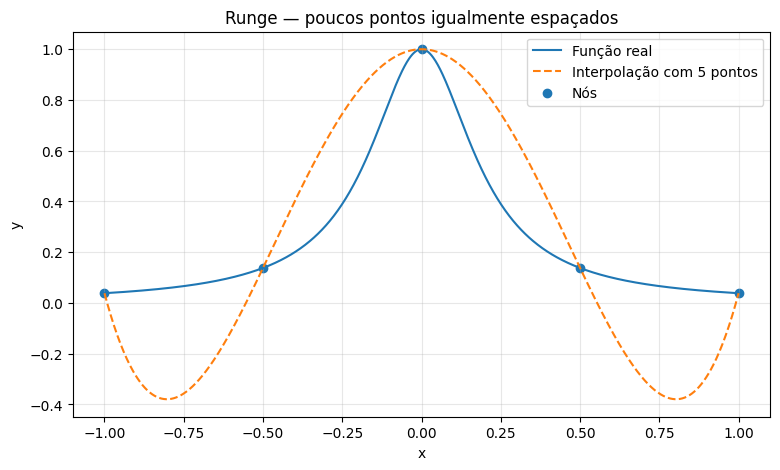

In [16]:
n = 5
xs_r = np.linspace(-1, 1, n)
ys_r = runge(xs_r)
coef_r = divided_differences(xs_r, ys_r)[0, :]
x_plot = np.linspace(-1, 1, 800)
y_interp_r = np.array([newton_interp(x, xs_r, coef_r) for x in x_plot])

plt.figure(figsize=(9,5))
plt.plot(x_plot, runge(x_plot), label="Função real")
plt.plot(x_plot, y_interp_r, "--", label=f"Interpolação com {n} pontos")
plt.scatter(xs_r, ys_r, label="Nós")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge — poucos pontos igualmente espaçados")
plt.legend()
plt.show()

### 10.3. Interpolação com mais pontos igualmente espaçados

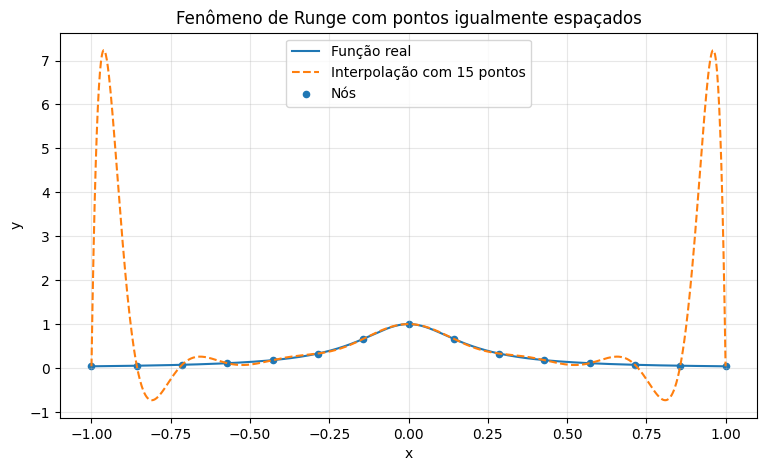

In [17]:
n = 15
xs_r = np.linspace(-1, 1, n)
ys_r = runge(xs_r)
coef_r = divided_differences(xs_r, ys_r)[0, :]
x_plot = np.linspace(-1, 1, 1200)
y_interp_r = np.array([newton_interp(x, xs_r, coef_r) for x in x_plot])

plt.figure(figsize=(9,5))
plt.plot(x_plot, runge(x_plot), label="Função real")
plt.plot(x_plot, y_interp_r, "--", label=f"Interpolação com {n} pontos")
plt.scatter(xs_r, ys_r, label="Nós", s=20)
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fenômeno de Runge com pontos igualmente espaçados")
plt.legend()
plt.show()

### 10.4. Erro no fenômeno de Runge

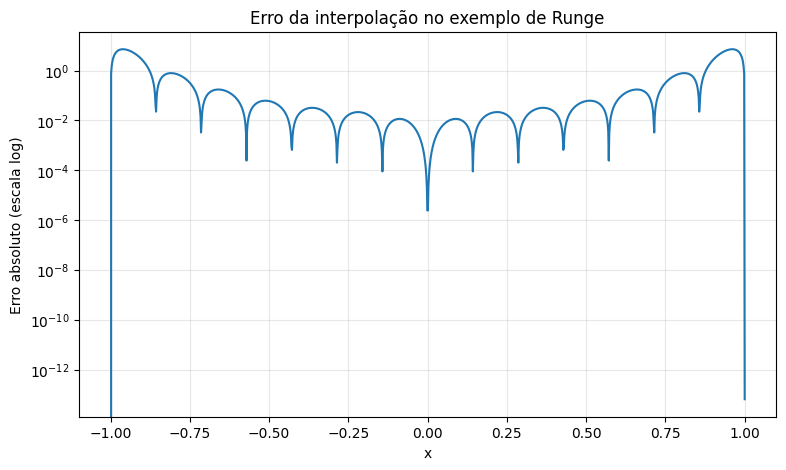

In [18]:
erro_runge = np.abs(runge(x_plot) - y_interp_r)

plt.figure(figsize=(9,5))
plt.plot(x_plot, erro_runge)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("Erro absoluto (escala log)")
plt.title("Erro da interpolação no exemplo de Runge")
plt.show()

## 11. Comentário didático sobre o fenômeno de Runge

O ponto principal não é apenas que “o erro cresce”, mas que:

- aumentar o grau do polinômio global **nem sempre melhora** a aproximação;
- a escolha dos nós importa muito;
- o problema é especialmente severo nas extremidades do intervalo.

Isso motiva, nas próximas aulas:

- **splines**;
- escolha mais adequada de nós, como **nós de Chebyshev**.

## 12. Comparação adicional: nós igualmente espaçados vs nós de Chebyshev

Sem aprofundar formalmente, já podemos visualizar que a distribuição dos pontos influencia muito a qualidade da interpolação.

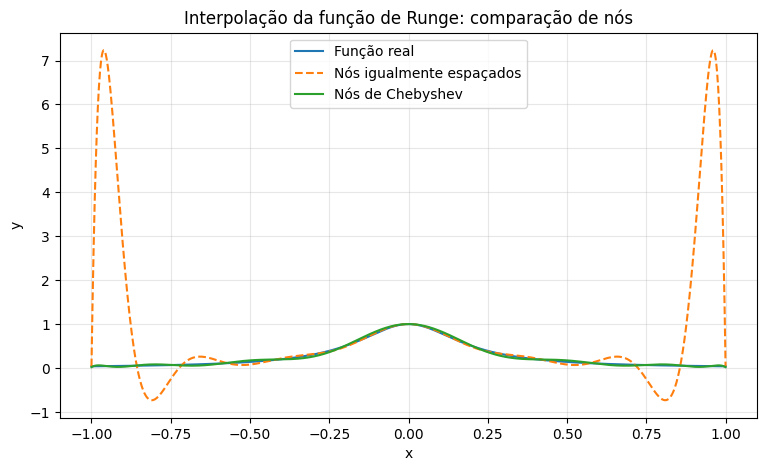

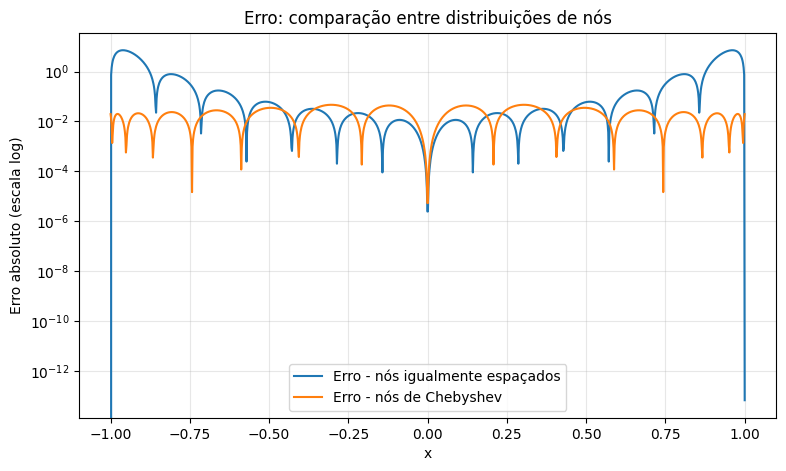

In [19]:
def chebyshev_nodes(a, b, n):
    k = np.arange(n)
    x = np.cos((2*k + 1) * np.pi / (2*n))
    return 0.5*(a+b) + 0.5*(b-a)*x

n = 15
xs_eq = np.linspace(-1, 1, n)
ys_eq = runge(xs_eq)
coef_eq = divided_differences(xs_eq, ys_eq)[0, :]

xs_ch = np.sort(chebyshev_nodes(-1, 1, n))
ys_ch = runge(xs_ch)
coef_ch = divided_differences(xs_ch, ys_ch)[0, :]

x_plot = np.linspace(-1, 1, 1200)
y_eq = np.array([newton_interp(x, xs_eq, coef_eq) for x in x_plot])
y_ch = np.array([newton_interp(x, xs_ch, coef_ch) for x in x_plot])
y_real = runge(x_plot)

plt.figure(figsize=(9,5))
plt.plot(x_plot, y_real, label="Função real")
plt.plot(x_plot, y_eq, "--", label="Nós igualmente espaçados")
plt.plot(x_plot, y_ch, label="Nós de Chebyshev")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolação da função de Runge: comparação de nós")
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.plot(x_plot, np.abs(y_real - y_eq), label="Erro - nós igualmente espaçados")
plt.plot(x_plot, np.abs(y_real - y_ch), label="Erro - nós de Chebyshev")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("Erro absoluto (escala log)")
plt.title("Erro: comparação entre distribuições de nós")
plt.legend()
plt.show()

## 13. Síntese da aula

Nesta aula vimos que:

1. o problema da interpolação busca um polinômio que passe exatamente pelos dados;
2. as formas de **Lagrange** e **Newton** são equivalentes matematicamente;
3. a forma de **Newton**, com diferenças divididas, é mais conveniente computacionalmente;
4. o erro depende da função e da distribuição dos nós;
5. polinômios globais de grau alto podem gerar oscilações indesejadas, como no **fenômeno de Runge**.

### Conexão com a próxima aula
Essas dificuldades motivam o estudo de **splines**, que constroem aproximações por partes e reduzem instabilidades.

## 14. Sugestões de exploração em sala

Você pode usar este notebook para propor rapidamente:

- alterar o conjunto de pontos do exemplo-base;
- comparar tempos de avaliação de Lagrange e Newton;
- testar outros valores de \(n\) no exemplo de Runge;
- explorar diferentes funções;
- comparar visualmente com splines em uma aula posterior.